In [137]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [138]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

import matplotlib.pyplot as plt
import joblib

In [139]:
df = pd.read_csv("/content/drive/MyDrive/AI_Society_Project/Heart_Dataset_BRFSS2015.csv")

X = df.drop("HeartDiseaseorAttack", axis=1)
y = df["HeartDiseaseorAttack"]

In [140]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=28
)

In [141]:
# scaler = StandardScaler()

# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

X_train_scaled = X_train
X_test_scaled = X_test

In [142]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print("scale_pos_weight:", scale)

scale_pos_weight: 9.573304157549234


In [143]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight= scale*0.7,
    random_state=42,
    reg_alpha=0.5,
    reg_lambda=1.5,
    eval_metric='logloss'
)

model.fit(X_train, y_train);

In [144]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [145]:
threshold = 0.4

y_pred = (y_prob > threshold).astype(int)

In [151]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print()
print("Classification Report:")
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.7361242510249133
Recall: 0.8137901681208768
ROC-AUC: 0.847856214435031

Classification Report:

              precision    recall  f1-score   support

         0.0       0.97      0.73      0.83     46037
         1.0       0.23      0.81      0.36      4699

    accuracy                           0.74     50736
   macro avg       0.60      0.77      0.60     50736
weighted avg       0.91      0.74      0.79     50736



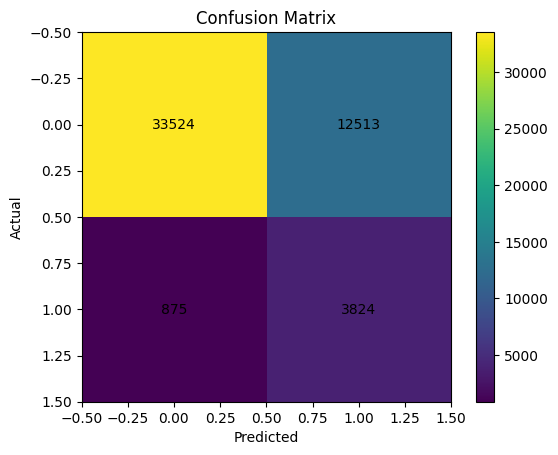

In [147]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

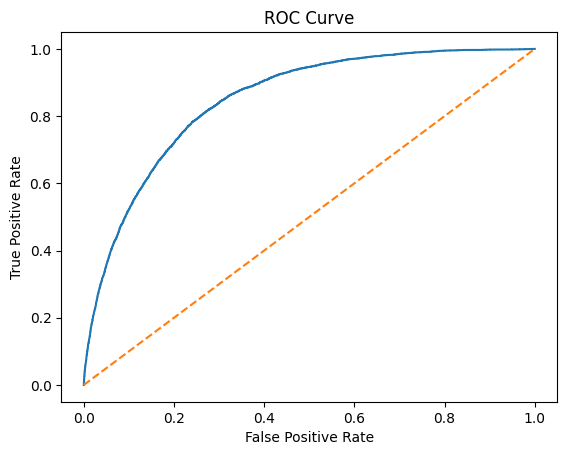

In [148]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [152]:
joblib.dump(model, "/content/drive/MyDrive/AI_Society_Project/model.pkl")
print("Done")

Done


In [153]:
files.download("/content/drive/MyDrive/AI_Society_Project/model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>